In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

def sort_lst(lst):
    sorted_lst = sorted(enumerate(lst), key=lambda x: x[1])
    indices = [i for i, _ in sorted_lst]
    values = [x for _, x in sorted_lst]
    return indices, values

: 

In [29]:
# path = '/mnt/home/xuezhiyu/results/adver_robustness/cifar10/1_resnet18_adver_avg_beta_0.5/linf-pgd_0.03137254901960784_0.00784313725490196_10/200_1024_0.4'
# path = '/mnt/home/xuezhiyu/results/adver_robustness/cifar100/1_resnet18_adver_avg_beta_1.0/linf-pgd_0.03137254901960784_0.00784313725490196_10/200_1024_0.4/'
# path = '/mnt/home/xuezhiyu/results/adver_robustness/cifar10/1_resnet18_adver_avg_beta_0.0/linf-pgd_0.03137254901960784_0.00784313725490196_10/200_1024_0.4'
path = '/mnt/home/xuezhiyu/results/adver_robustness/cifar100/1_resnet34_adver_avg_beta_1.0/linf-pgd_0.03137254901960784_0.00784313725490196_10/200_1024_0.4'

grad_track_layers_files = [i for i in os.listdir(path) if 'grad_track_layers' in i]
grad_track_layers_idx,grad_track_layers_values = sort_lst([int(i.split('_')[0]) for i in grad_track_layers_files])
grad_track_layers_files = np.array(grad_track_layers_files)[grad_track_layers_idx].tolist()

grad_track_files = [i for i in os.listdir(path) if 'grad_track.csv' in i]
grad_track_idx,grad_track_values = sort_lst([int(i.split('_')[0]) for i in grad_track_files])
grad_track_files = np.array(grad_track_layers_files)[grad_track_idx].tolist()

Text(0, 0.5, 'Value')

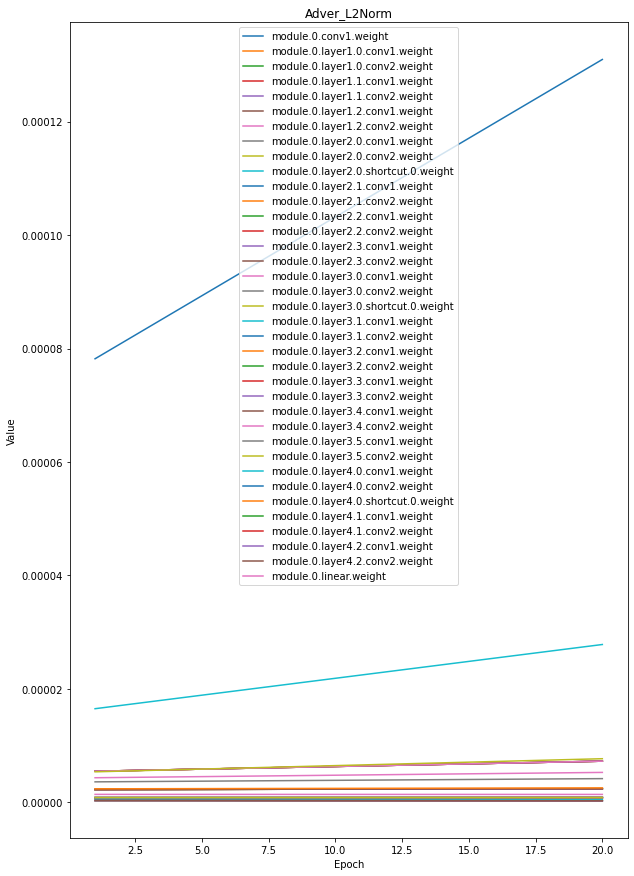

In [30]:
metric = 'Conflict'
metric = 'Cos'
# metric =  'Eucli'
# metric = 'Clean_L2Norm'
metric = 'Adver_L2Norm'
norm = True

res = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res = pd.DataFrame(res).set_index([epoch]) 
Dim = df.loc['Dim']

if norm:
    res = res.append(Dim)
    res = res.drop(columns=res.columns[res.eq(0).all()], axis=1)
    res = (res / res.loc['Dim']).drop(index=['Dim'])
else:
    res = res.drop(columns=res.columns[res.eq(0).all()], axis=1)
# plt.figure(figsize=[0,100])
res.plot(figsize=[10,15])
plt.title(metric)
plt.xlabel('Epoch')
plt.ylabel('Value')
    

In [ ]:
# Comparison study of gradient l2 norm from different layers
 
metric = 'Clean_L2Norm'
# metric = 'Adver_L2Norm'
res_clean = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res_clean.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res_clean = pd.DataFrame(res_clean).set_index([epoch]) 
res_clean = res_clean.drop(columns=res_clean.columns[res_clean.eq(0).all()], axis=1)


# metric = 'Clean_L2Norm'
metric = 'Adver_L2Norm'
res_adver = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res_adver.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res_adver = pd.DataFrame(res_adver).set_index([epoch]) 
res_adver = res_adver.drop(columns=res_adver.columns[res_adver.eq(0).all()], axis=1)


for i in epoch:
    data_epoch = pd.concat([res_clean.loc[i],res_adver.loc[i],res_adver.loc[i]-res_clean.loc[i]],axis=1,keys=['clean_l2','adver_l2','dif_l2'])
    data_epoch.plot(kind='bar')
    plt.title('Epoch='+str(i))

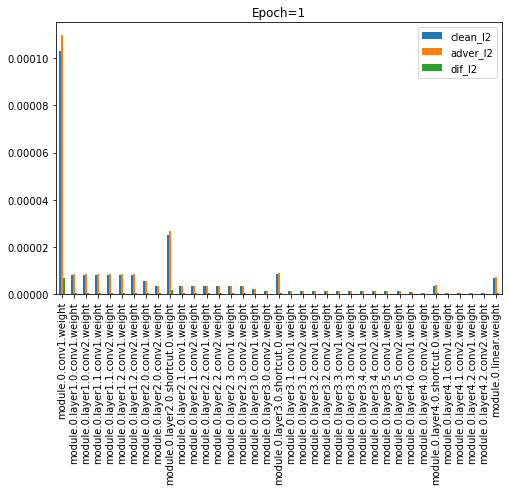

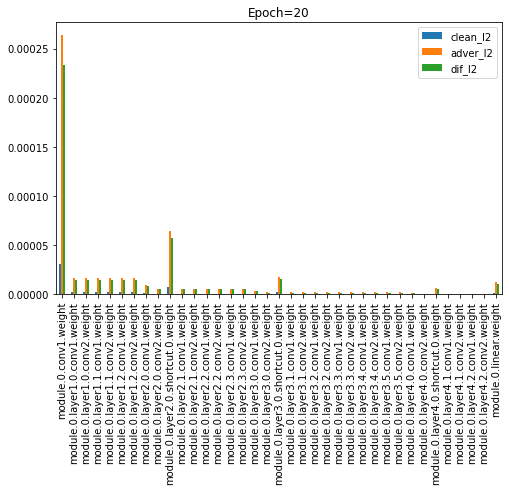

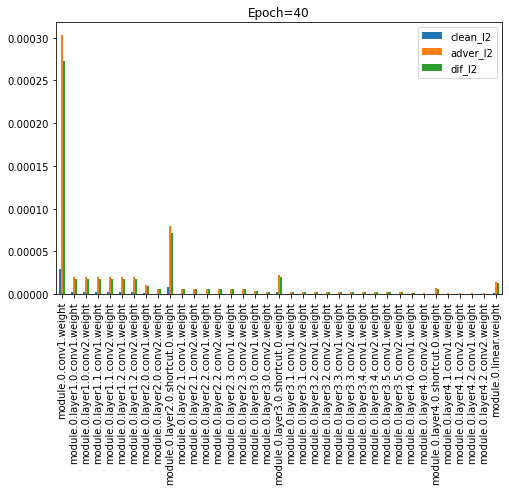

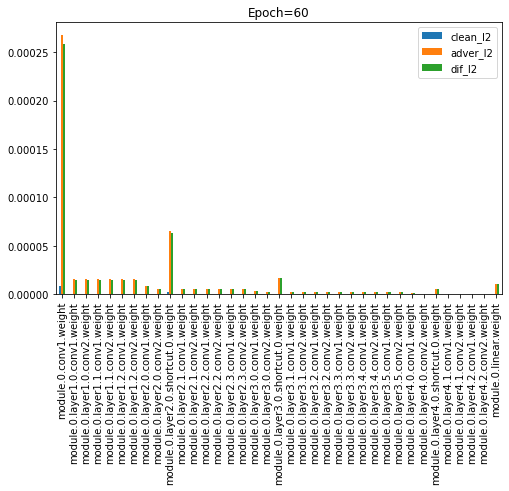

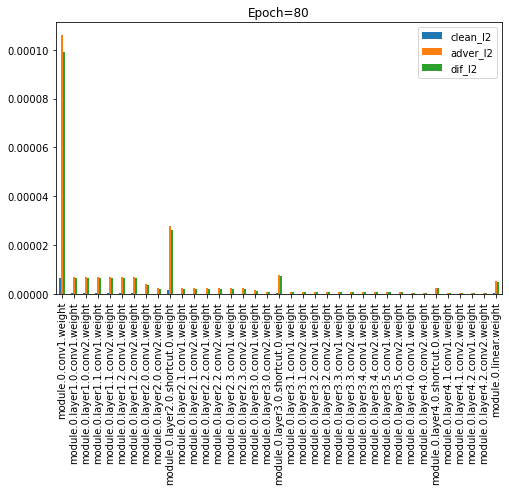

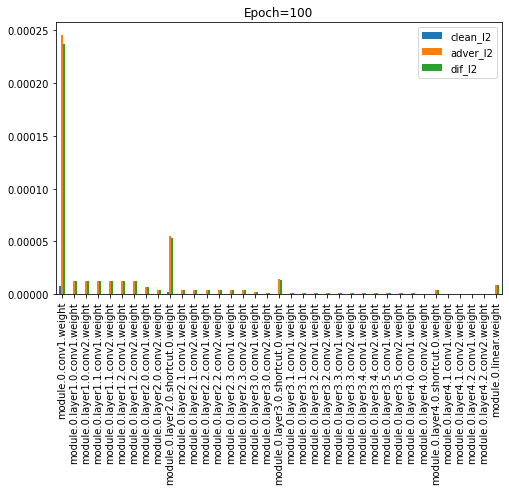

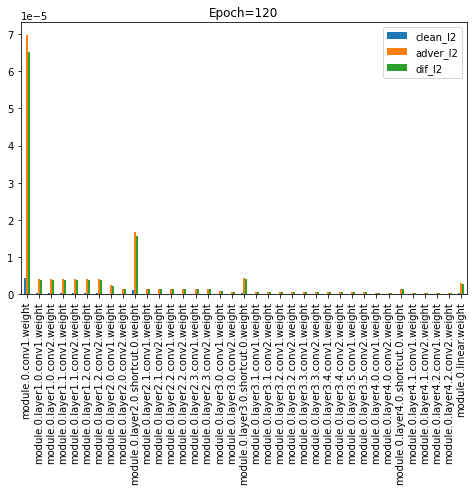

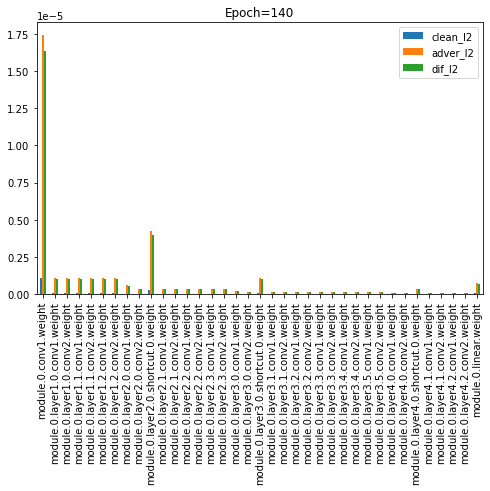

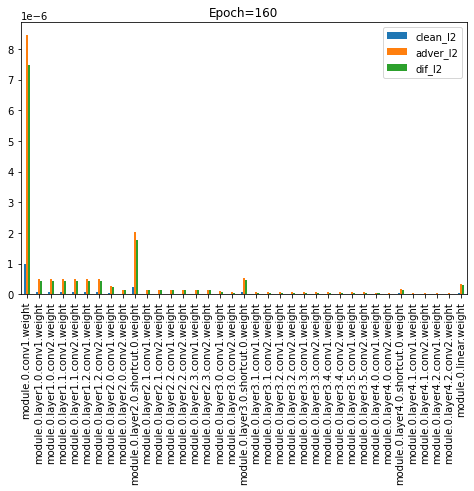

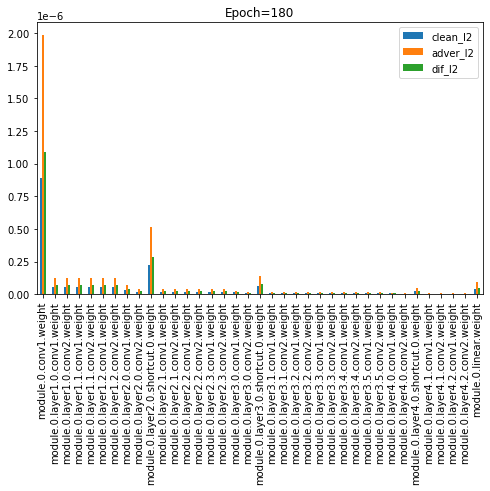

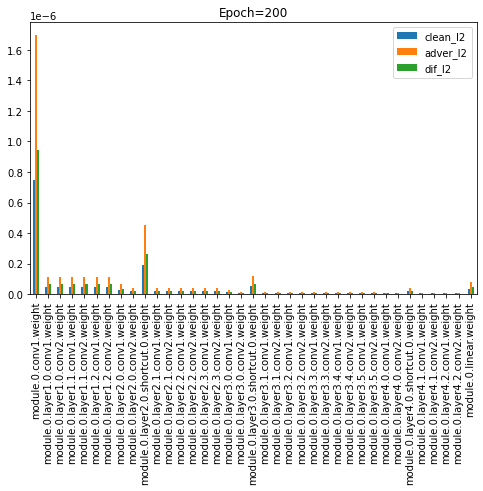

In [ ]:
# Comparison study of gradient normed l2 norm from different layers
 
metric = 'Clean_L2Norm'
# metric = 'Adver_L2Norm'
res_clean = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res_clean.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res_clean = pd.DataFrame(res_clean).set_index([epoch]) 
Dim = df.loc['Dim']
res_clean = res_clean.append(Dim)
res_clean = res_clean.drop(columns=res_clean.columns[res_clean.eq(0).all()], axis=1)
res_clean = (res_clean / res_clean.loc['Dim']).drop(index=['Dim'])


# metric = 'Clean_L2Norm'
metric = 'Adver_L2Norm'
res_adver = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res_adver.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res_adver = pd.DataFrame(res_adver).set_index([epoch]) 
Dim = df.loc['Dim']
res_adver = res_adver.append(Dim)
res_adver = res_adver.drop(columns=res_adver.columns[res_adver.eq(0).all()], axis=1)
res_adver = (res_adver / res_adver.loc['Dim']).drop(index=['Dim'])

for i in epoch:
    # plt.figure(figsize=[5,10])
    data_epoch = pd.concat([res_clean.loc[i],res_adver.loc[i],res_adver.loc[i]-res_clean.loc[i]],axis=1,keys=['clean_l2','adver_l2','dif_l2'])
    data_epoch.plot(kind='bar',figsize=[8,5])
    plt.title('Epoch='+str(i))

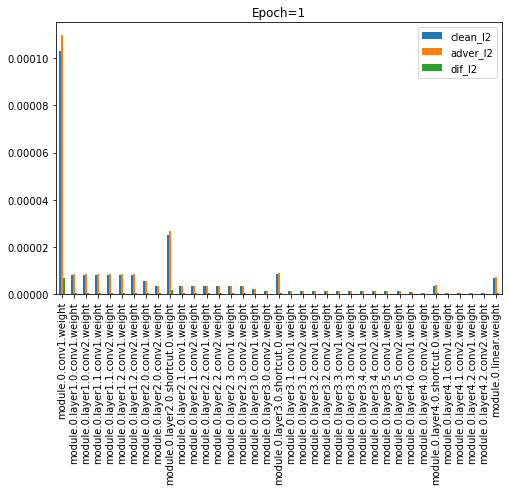

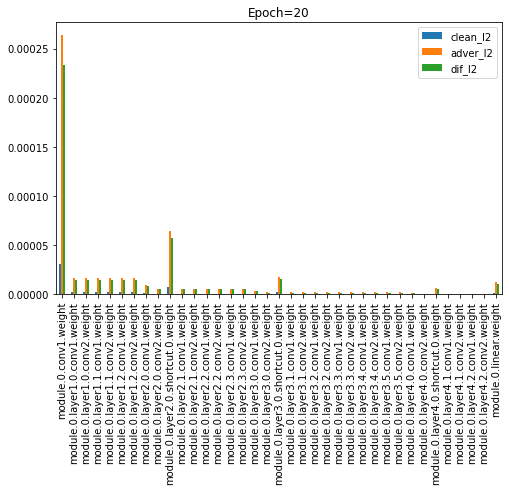

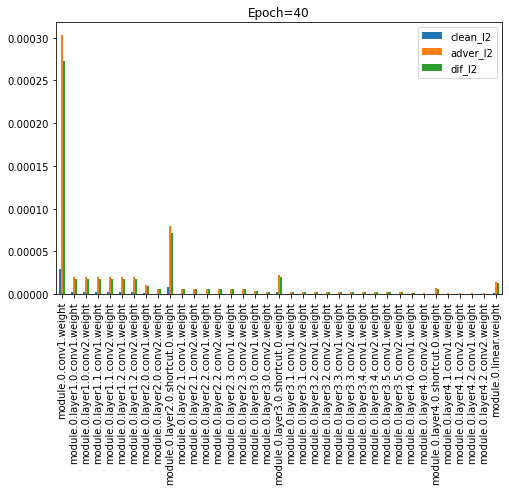

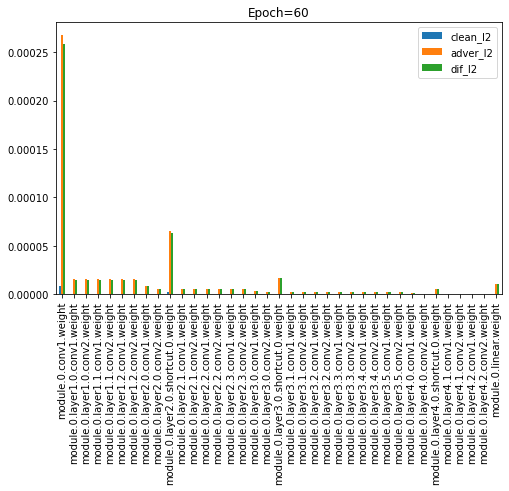

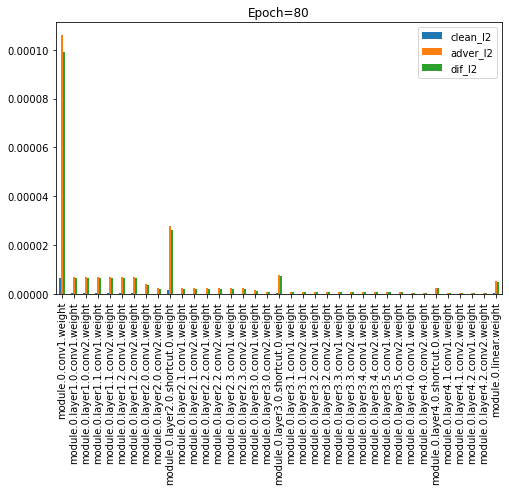

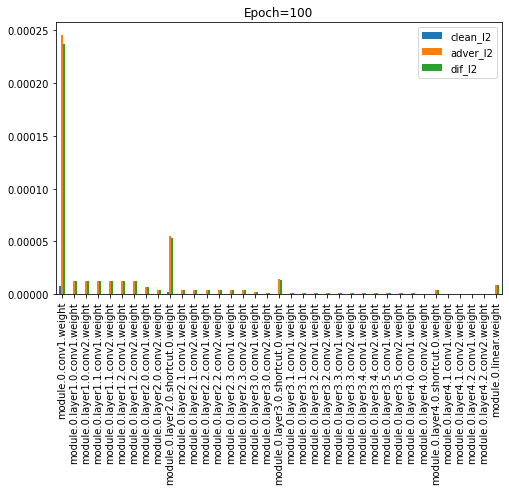

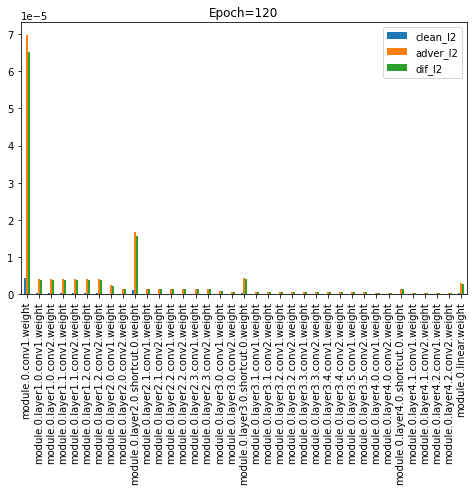

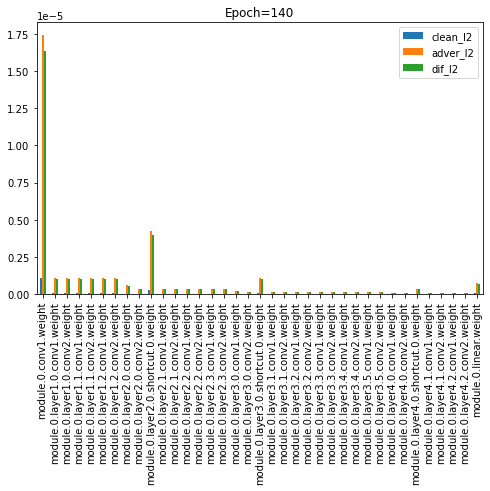

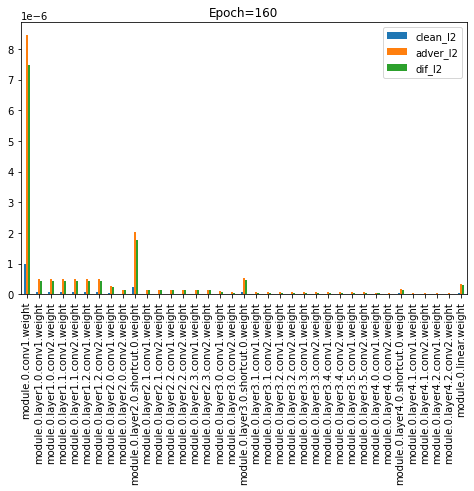

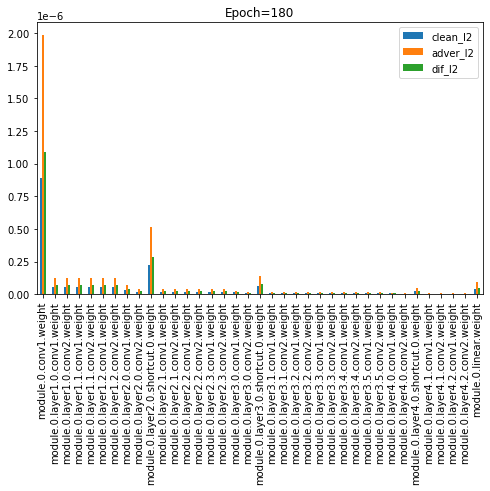

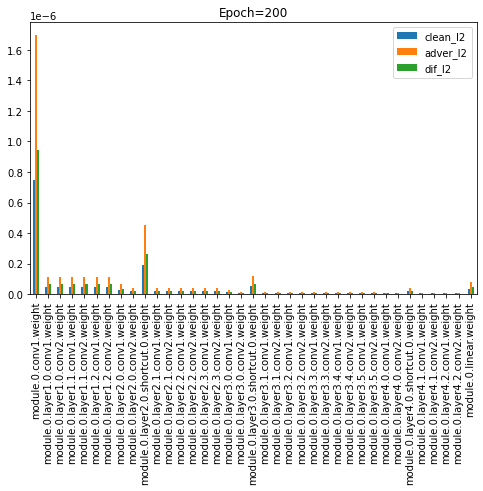

In [ ]:
metric = 'Cos'
res_cos = []
epoch = []
for file in grad_track_layers_files:
    file_path = os.path.join(path,file) 
    df = pd.read_csv(file_path)
    df = df.set_index('Unnamed: 0')
    res_cos.append(df.loc[metric,:])
    epoch.append(int(file.split('_')[0]))

res_cos = pd.DataFrame(res_cos).set_index([epoch]) 
res_cos = res_cos.drop(columns=res_cos.columns[res_cos.eq(0).all()], axis=1)

for i in epoch:
    # plt.figure(figsize=[5,10])
    data_epoch = pd.concat([res_clean.loc[i],res_adver.loc[i],res_adver.loc[i]-res_clean.loc[i]],axis=1,keys=['clean_l2','adver_l2','dif_l2'])
    data_epoch.plot(kind='bar',figsize=[8,5])
    plt.title('Epoch='+str(i))